In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.dates as mdates
from src.fonction_analyse import compter_par_mois, evolution_mensuelle, nb_accidents_par, tab_cont_grav, bar_chart

# %run main.ipynb

# df_caract_recoder
# df_lieux_recoder
# df_vehicule_recoder
# df_usager_recoder
# df_final

In [95]:
import importlib
import src.fonction_analyse

importlib.reload(src.fonction_analyse)

<module 'src.fonction_analyse' from '/home/onyxia/work/Projet_pythonDS/src/fonction_analyse.py'>

In [96]:
ordre_colonnes = [
    "Indemne", 
    "Blessé léger", 
    "Blessé hospitalisé", 
    "Tué"
]

## Visualisation des données

In [97]:
df_final.head(3)

,Num_Acc,jour,mois,an,hrmn,lum,dep,agg,int,atm,...,id_usager,catu,grav,sexe,trajet,secu1,age,date,jour_semaine,hr
0,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,Hors agglomération,Hors intersection,Brouillard - fumée,...,203 988 581,Conducteur,Blessé hospitalisé,Homme,Domicile - École,Ceinture,23,2024-03-25,Lundi,07
1,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,Hors agglomération,Hors intersection,Brouillard - fumée,...,203 988 582,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,29,2024-03-25,Lundi,07
2,202400000002,20,mars,2024,15:05,Plein jour,21,En agglomération,Intersection en T,Temps éblouissant,...,203 988 579,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,99,2024-03-20,Mercredi,15


In [98]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 367699 entries, 0 to 377701
Data columns (total 40 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Num_Acc       367699 non-null  Int64         
 1   jour          367699 non-null  int64         
 2   mois          367699 non-null  object        
 3   an            367699 non-null  int64         
 4   hrmn          367699 non-null  object        
 5   lum           367699 non-null  object        
 6   dep           367699 non-null  object        
 7   agg           367699 non-null  object        
 8   int           367699 non-null  object        
 9   atm           367699 non-null  object        
 10  col           367699 non-null  object        
 11  lat           367699 non-null  object        
 12  long          367699 non-null  object        
 13  mois_num      367699 non-null  int64         
 14  catr          367699 non-null  object        
 15  circ          345149 n

`describe` nous renseigne sur la distribution des variables numériques :

In [99]:
df_final.describe()

,Num_Acc,jour,an,mois_num,vma,age,date
count,367699.0,367699.000000,367699.000000,367699.000000,367699.000000,367699.0,367699
mean,202299675571.364563,15.550197,2022.996481,6.658762,58.701378,41.752953,2023-07-04 20:18:36.639425024
min,202200000001.0,1.000000,2022.000000,1.000000,-1.000000,2.0,2022-01-01 00:00:00
25%,202200041217.5,8.000000,2022.000000,4.000000,50.000000,26.0,2022-09-28 00:00:00
50%,202300027260.0,15.000000,2023.000000,7.000000,50.000000,38.0,2023-07-07 00:00:00
75%,202400013566.5,23.000000,2024.000000,10.000000,80.000000,55.0,2024-04-09 00:00:00
max,202400054402.0,31.000000,2024.000000,12.000000,900.000000,113.0,2024-12-31 00:00:00
std,81705646.139283,8.741702,0.817058,3.353165,27.757948,19.146413,NaN


## Évolution du nombre d'accidents dans le temps

### Évolution globale

In [100]:
nb_accidents_par(df_final, "an", "Année")


TypeError: Series.reset_index() got an unexpected keyword argument 'names'. Did you mean 'name'?

Le nombre d'accidents est comparable entre les trois années.

On observe une légère tendance à la hausse, malgré des variations assez importantes selon les périodes.

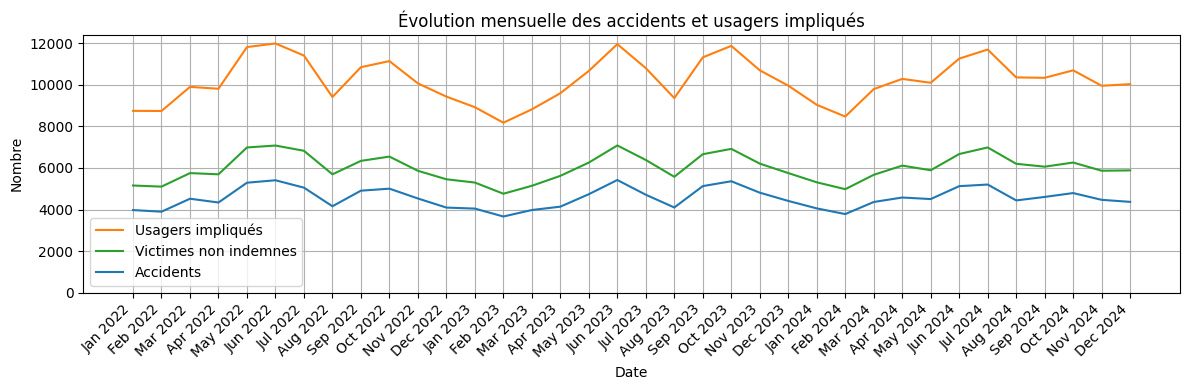

In [ ]:
evolution_mensuelle(df_final)

### Évolution horaire

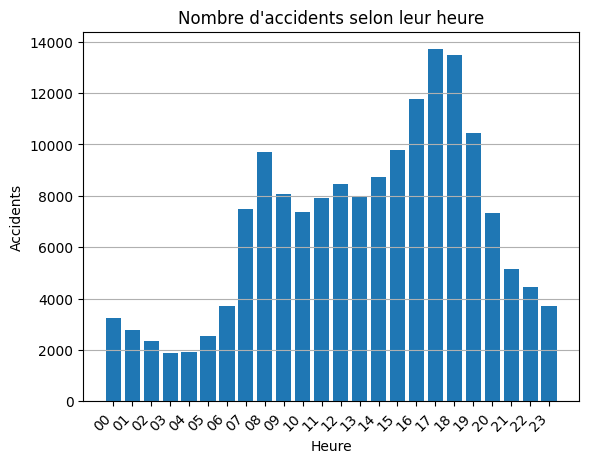

In [ ]:
nb_accidents_par(df_final, "hr", "Heure")

On observe deux modes aux heures de pointes, à 8 et 17 heures. Les accidents sont ensuite plus nombreux de jour que de nuit, et on peut supposer que leur nombre reflète globalement le trafic.

In [ ]:
ordre = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
nb_accidents_par(df_final, "jour_semaine", "Jour de la semaine", ordre, True)

TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'. Did you mean 'names'?

## Nombre et gravité des accidents selon les facteurs extérieurs

### Tests

In [ ]:
def test_chi2(variable1, variable2):
    tc = pd.crosstab(df_final[variable1], df_final[variable2])
    chi2, p_value, dof, expected = chi2_contingency(tc)
    print(f"Chi² = {chi2:.2f}")
    print(f"p-value = {p_value:.4f}")
    print(f"Degrés de liberté = {dof}")

In [ ]:
chi2_contingency(tc_atm_grav)

Chi2ContingencyResult(statistic=np.float64(2.0920811885096238), pvalue=np.float64(0.9999999999699046), dof=27, expected_freq=array([[0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871],
       [0.38407938, 0.38938368, 0.15795822, 0.06857871]]))

In [ ]:
test_chi2("atm", "grav")

Chi² = 1534.37
p-value = 0.0000
Degrés de liberté = 27


### Conditions routières


#### Catégorie de route

In [ ]:
ordre_lignes = [
    "Autoroute",
    "Route nationale",
    "Route départementale",
    "Voie communale",
    "Hors réseau public",
    "Parc de stationnement ouvert à la circulation publique",
    "Route de métropole urbaine",
    "Autre"
]
nb_accidents_par(df_final, "catr", "Catégorie de route", ordre_lignes, True)

TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'. Did you mean 'names'?

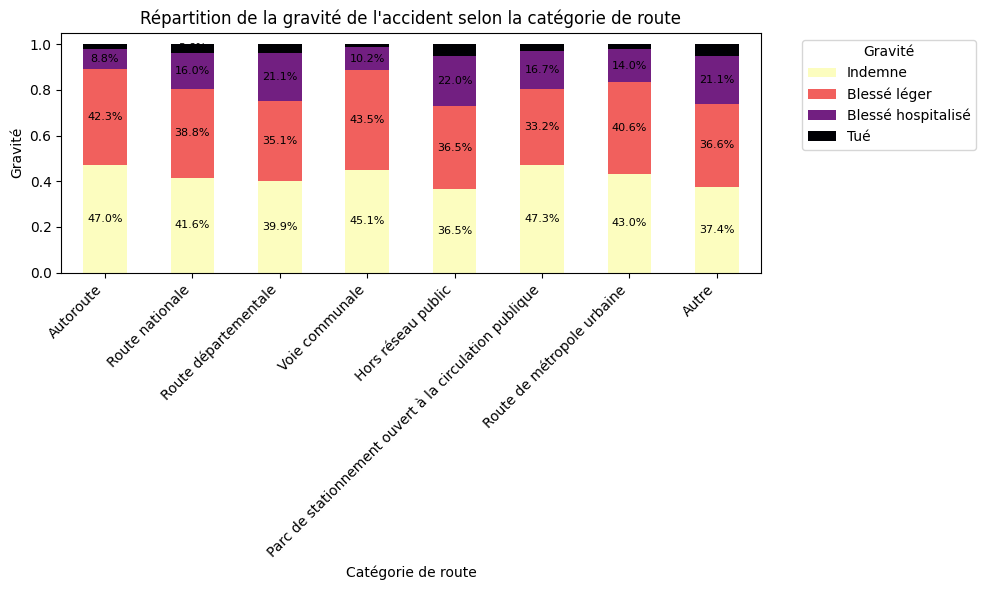

In [ ]:
tc_catr_grav = tab_cont_grav(df_final, "catr", ordre_lignes, ordre_colonnes)
bar_chart(tc_catr_grav, "Catégorie de route", "Répartition de la gravité de l'accident selon la catégorie de route")

#### Agglomération

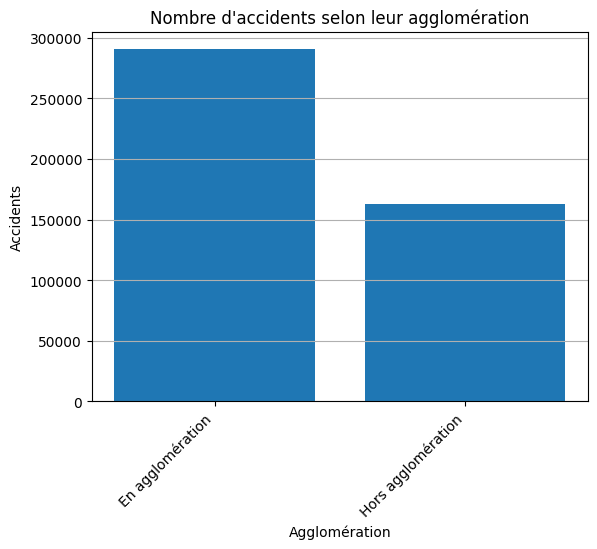

In [ ]:
nb_accidents_par(df_final, "agg", "Agglomération")

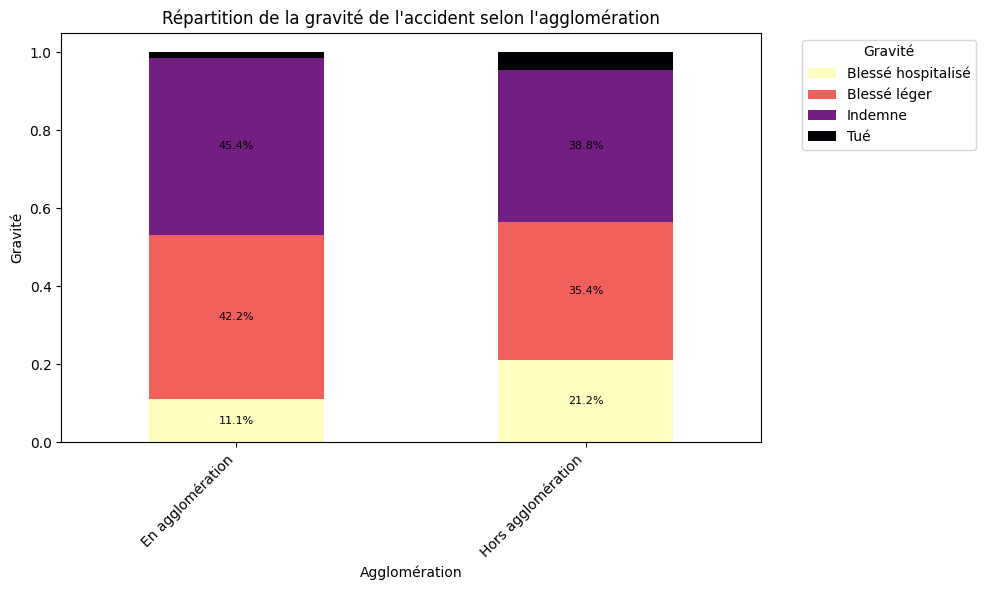

In [ ]:

tc_agg_grav = pd.crosstab(df_final["agg"], df_final["grav"], normalize='index')
bar_chart(tc_agg_grav, "Agglomération", "Répartition de la gravité de l'accident selon l'agglomération")

### Conditions atmosphériques et météorologiques

#### Conditions d'éclairage

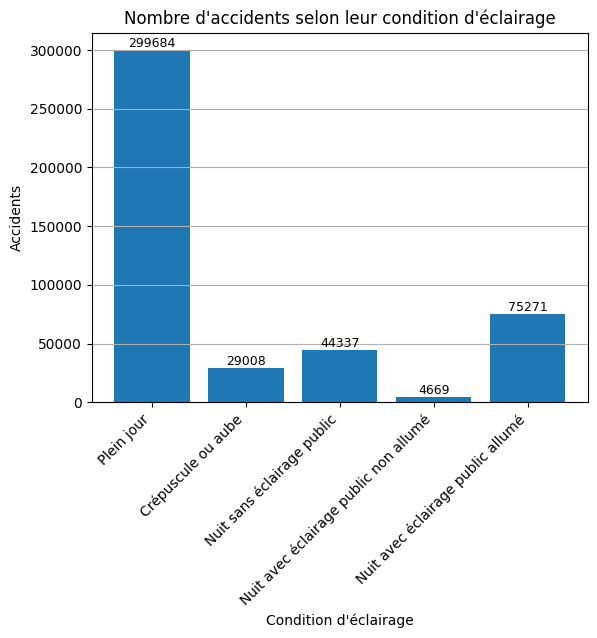

In [ ]:
ordre_lignes  = [
    "Plein jour",
    "Crépuscule ou aube",
    "Nuit sans éclairage public",
    "Nuit avec éclairage public non allumé",
    "Nuit avec éclairage public allumé"
]

nb_accidents_par(df_final, "lum", "Condition d'éclairage", ordre_lignes, True)

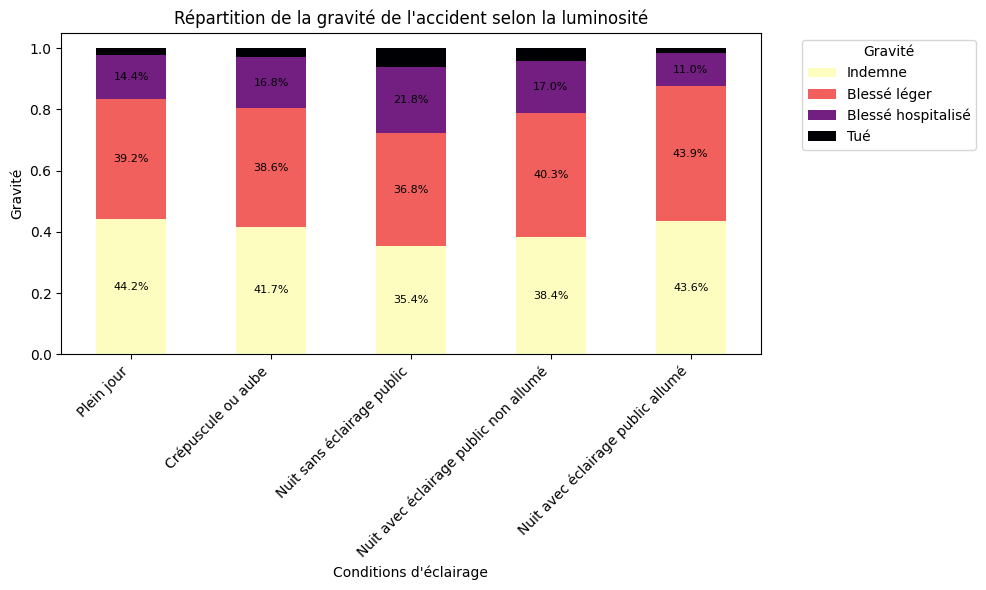

In [ ]:


tc_lum_grav = tab_cont_grav(df_final, "lum", ordre_lignes, ordre_colonnes)
bar_chart(tc_lum_grav, "Conditions d'éclairage", "Répartition de la gravité de l'accident selon la luminosité")

#### Conditions atmosphériques

In [ ]:
nb_accidents_par(df_final, "atm", "Condition atmosphérique", ordre_lignes, True)

TypeError: nb_accidents_par() takes from 3 to 4 positional arguments but 5 were given

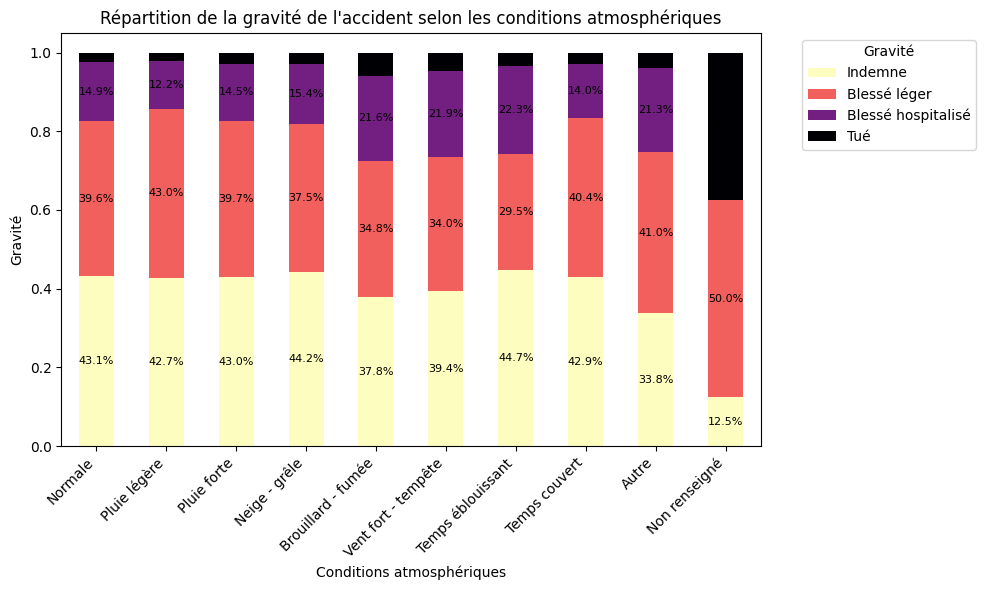

In [ ]:
ordre_lignes  = [
    "Normale", 
    "Pluie légère", 
    "Pluie forte", 
    "Neige - grêle", 
    "Brouillard - fumée", 
    "Vent fort - tempête", 
    "Temps éblouissant", 
    "Temps couvert", 
    "Autre", 
    "Non renseigné"
]

tc_atm_grav = tab_cont_grav(df_final, "atm", ordre_lignes, ordre_colonnes)

bar_chart(tc_atm_grav, "Conditions atmosphériques", "Répartition de la gravité de l'accident selon les conditions atmosphériques")

#### Conditions de la surface au sol

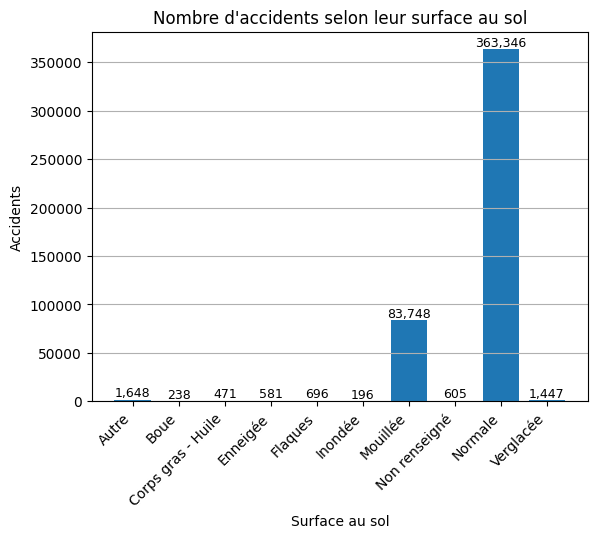

In [ ]:
nb_accidents_par(df_final, "surf", "Surface au sol", True)

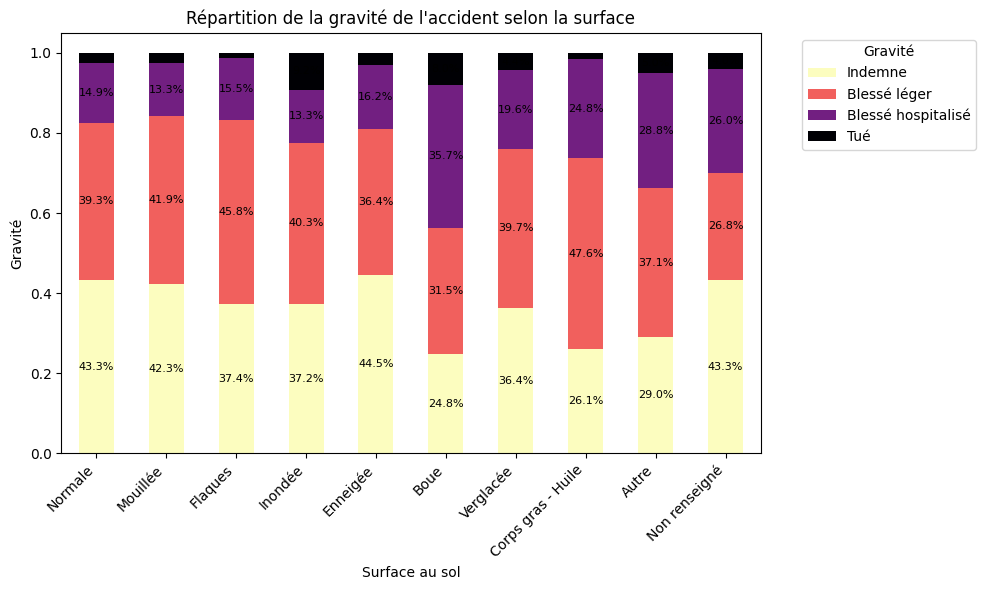

In [ ]:
ordre_lignes = [
   "Normale",
   "Mouillée",
   "Flaques",
   "Inondée",
   "Enneigée",
   "Boue",
   "Verglacée",
   "Corps gras - Huile",
   "Autre",
   "Non renseigné"
]

tc_surf_grav = tab_cont_grav(df_final, "surf", ordre_lignes, ordre_colonnes)
bar_chart(tc_surf_grav, "Surface au sol", "Répartition de la gravité de l'accident selon la surface")

La proportion de tués est plus grande lorsque les accidents ont lieu sur des surfaces inondées (9,2 %) ou boueuses (8,0 %) par rapport aux autres situations. La part de blessés hospitalisées est particulièrement importante dans ce second cas (35,7 %), alors qu'il n'excède pas 25 % quand la surface est spécifiée.

### Conditions de l'accident

#### Type de collision

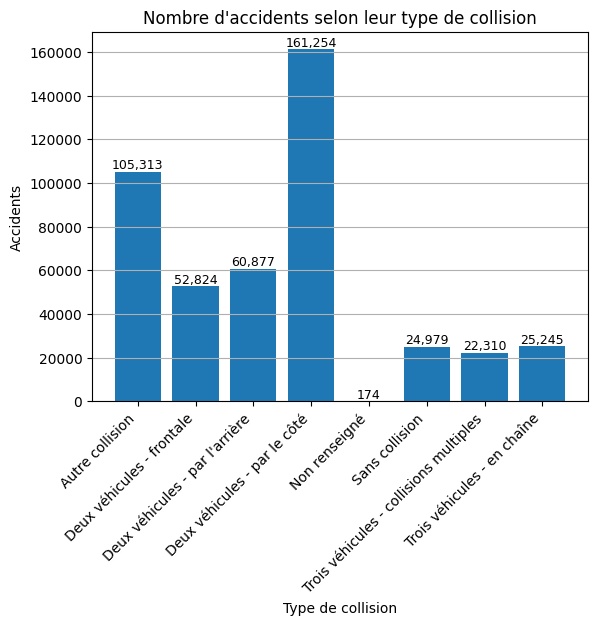

In [ ]:
nb_accidents_par(df_final, "col", "Type de collision", True)

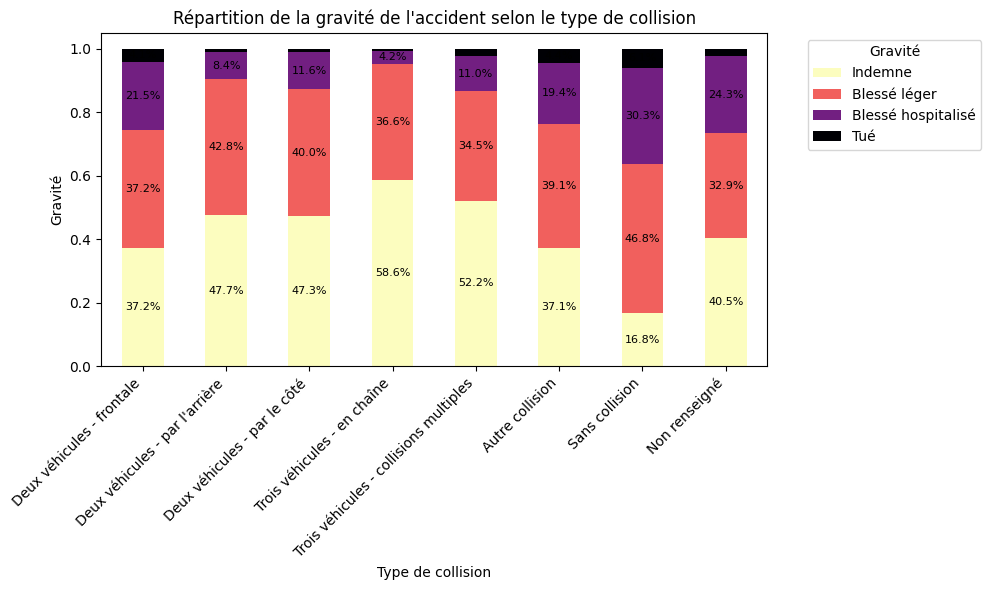

In [ ]:
ordre_lignes = [
    "Deux véhicules - frontale",
    "Deux véhicules - par l'arrière",
    "Deux véhicules - par le côté",
    "Trois véhicules - en chaîne",
    "Trois véhicules - collisions multiples",
    "Autre collision",
    "Sans collision",
    "Non renseigné"
]

tc_col_grav = tab_cont_grav(df_final, "col", ordre_lignes, ordre_colonnes)
bar_chart(tc_col_grav, "Type de collision", "Répartition de la gravité de l'accident selon le type de collision")

L'absence de collision est le cas le plus fatal parmi les situations où le type de collision est spécifié, et c'est aussi le cas avec le moins d'indemnes : seulement 16,8 %. Elle est suivie par la collision frontale entre deux véhicules, puis par le cas de collisions multiples entre trois véhicules. On remarque que pour les collisions entre trois véhicules, plus de la moitié des usagers impliqués dans l'accident s'en sortent indemnes.

#### Obstacle fixe percuté

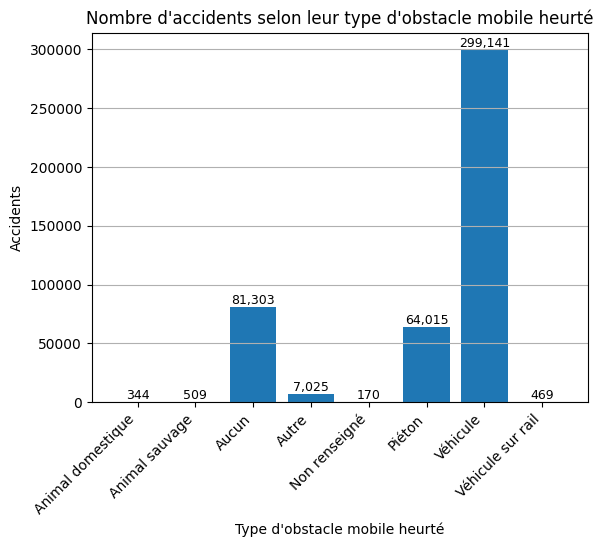

In [ ]:
nb_accidents_par(df_final, "obsm", "Type d'obstacle mobile heurté", True)

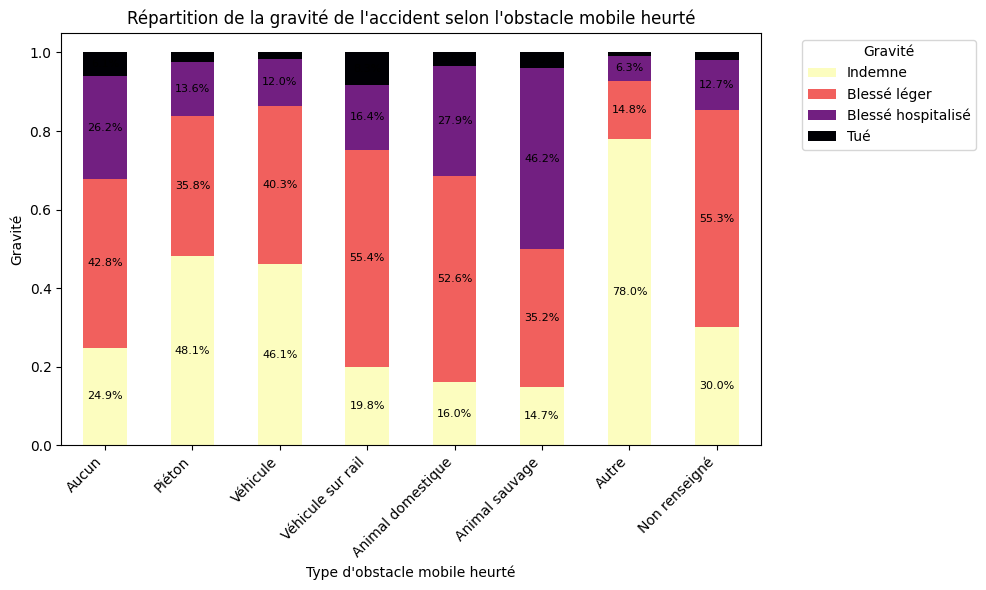

In [ ]:
ordre_lignes = [
    "Aucun",
    "Piéton",
    "Véhicule",
    "Véhicule sur rail",
    "Animal domestique",
    "Animal sauvage",
    "Autre",
    "Non renseigné"
]

tc_obsm_grav = tab_cont_grav(df_final, "obsm", ordre_lignes, ordre_colonnes)
bar_chart(tc_obsm_grav, "Type d'obstacle mobile heurté", "Répartition de la gravité de l'accident selon l'obstacle mobile heurté")

#### Obstacle fixe

In [ ]:
ordre_lignes = [
    "Sans objet",
    "Véhicule en stationnement",
    "Arbre",
    "Glissière métallique",
    "Glissière béton",
    "Autre glissière",
    "Bâtiment, mur, pile de pont",
    "Support de signalisation verticale ou poste d’appel d’urgence",
    "Poteau",
    "Mobilier urbain",
    "Parapet",
    "Ilot, refuge, borne haute",
    "Bordure de trottoir",
    "Fossé, talus, paroi rocheuse",
    "Autre obstacle fixe sur chaussée",
    "Autre obstacle fixe sur trottoir ou accotement",
    "Sortie de chaussée sans obstacle",
    "Buse – tête d’aqueduc",
    "Non renseigné"
]

nb_accidents_obs = (
    df_final.groupby("obs")
    .count()
    .reset_index()
    .iloc[:, :2]
    .rename(columns={"obs": "Obstacle fixe heurté"})
    .rename(columns={"Num_Acc": "Nombre d'accidents"})
    .set_index("Obstacle fixe heurté")
    .reindex(ordre_lignes)
    .reset_index()
)
nb_accidents_obs

,Obstacle fixe heurté,Nombre d'accidents
0,Sans objet,384296
1,Véhicule en stationnement,10189
2,Arbre,7485
3,Glissière métallique,5928
4,Glissière béton,6154
5,Autre glissière,871
6,"Bâtiment, mur, pile de pont",5781
7,Support de signalisation verticale ou poste d’...,1487
8,Poteau,6092
9,Mobilier urbain,2654


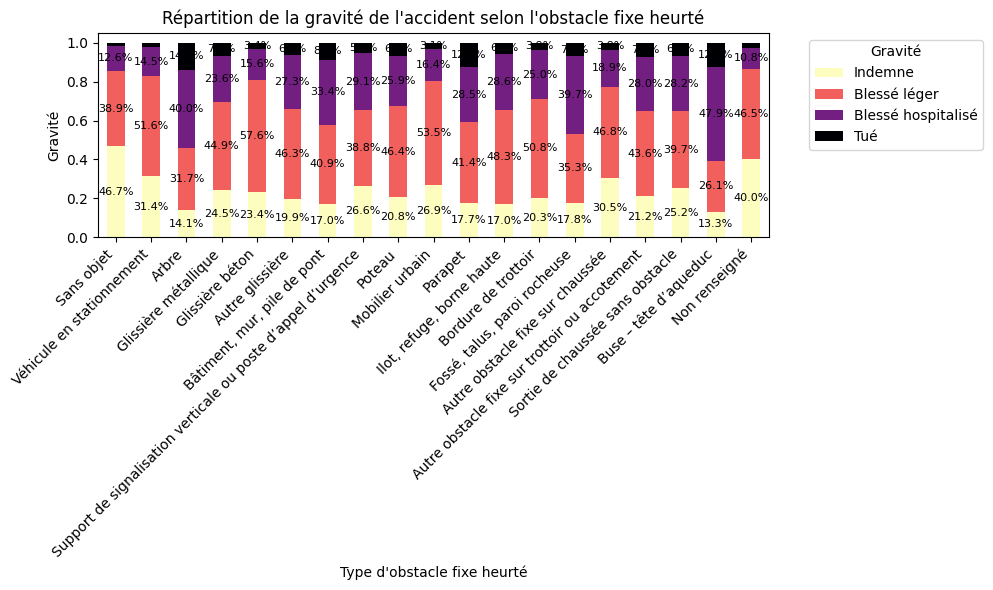

In [ ]:

tc_obs_grav = tab_cont_grav(df_final, "obs", ordre_lignes, ordre_colonnes)
bar_chart(tc_obs_grav, "Type d'obstacle fixe heurté", "Répartition de la gravité de l'accident selon l'obstacle fixe heurté")

TypeError: 'value' must be an instance of str or bytes, not a int

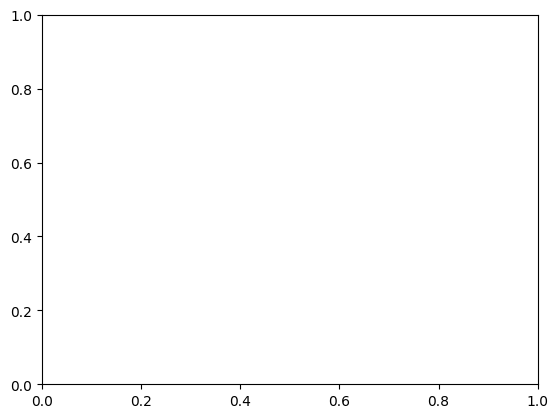

In [ ]:
sns.boxplot(data=df_final, x="grav", y="nbv")

plt.title("Distribution du nombre de voies selon la gravité")
plt.xlabel("Gravité")
plt.ylabel("Nombre de voies")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

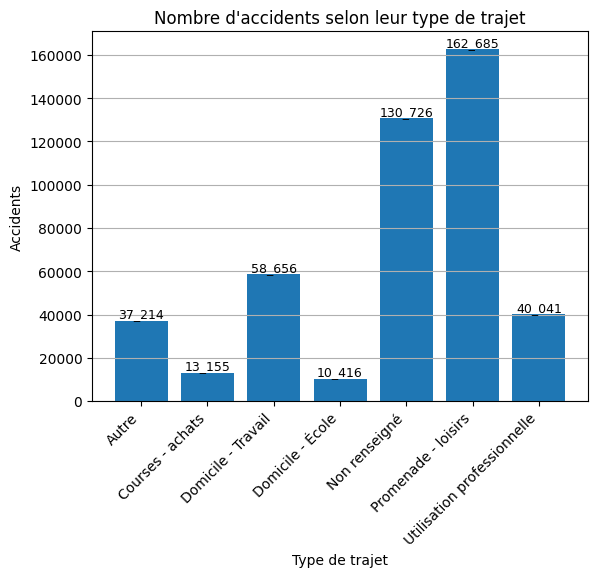

In [ ]:

nb_accidents_par(df_final, "trajet", "Type de trajet", True)

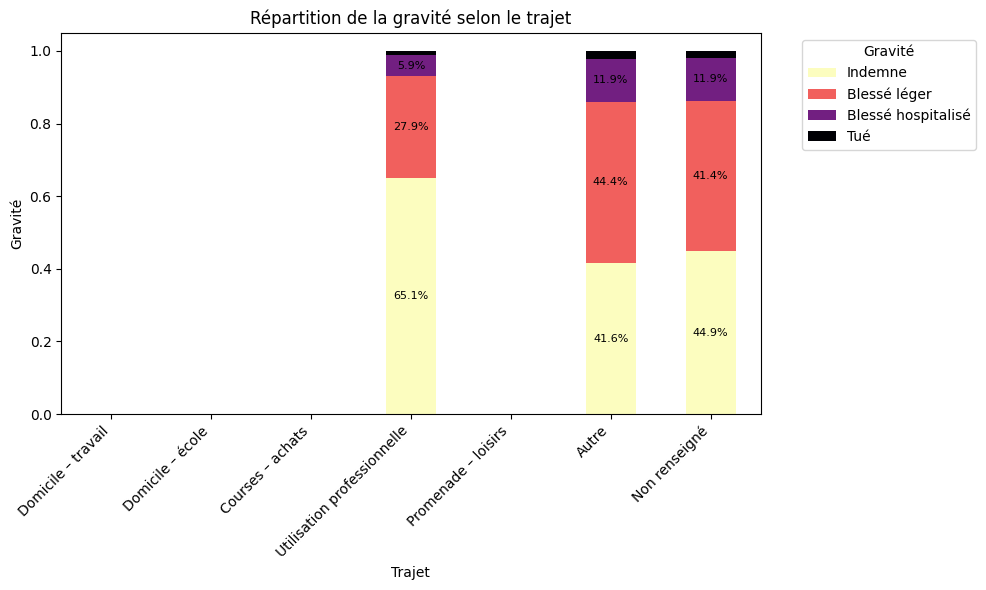

In [ ]:
ordre_lignes = [
    "Domicile – travail",
    "Domicile – école",
    "Courses – achats",
    "Utilisation professionnelle",
    "Promenade – loisirs",
    "Autre",
    "Non renseigné"
]

tc_trajet_grav = tab_cont_grav(df_final, "trajet", ordre_lignes, ordre_colonnes)
bar_chart(tc_trajet_grav, "Trajet", "Répartition de la gravité selon le trajet")